Finding featuers using random forest

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Selected features: ['principal_upper_sec_plus_edu', 'principal_female', 'pagoda_preschool_schools', 'g7_intake_aged12', 'teaching_staff_edu_lower_sec', 'num_buildings_total', 'classrooms_poor_wall', 'schools_with_office', 'schools_with_library', 'pb_fund_per_student_riel', 'pb_fund_per_school_riel', 'funding_abroad', 'sex_ratio_aged15_17', 'pupils_per_school', 'buildings_per_school', 'pct_schools_in_pagoda', 'pct_students_lower_sec', 'net_admission_rate_total', 'net_admission_rate_girl', 'transition_rate_upper_sec_girl']

--- Cross‑validation (Training Set) ---
CV R² scores: [-0.93210642  0.48548126  0.32187165 -0.65098239  0.36323035]
Mean CV R²: -0.0825 (+/- 1.1764)

--- Test Set Performance (2024‑2026) ---
R²:   -1.3148
RMSE: 11.1797
MAE:  9.3483


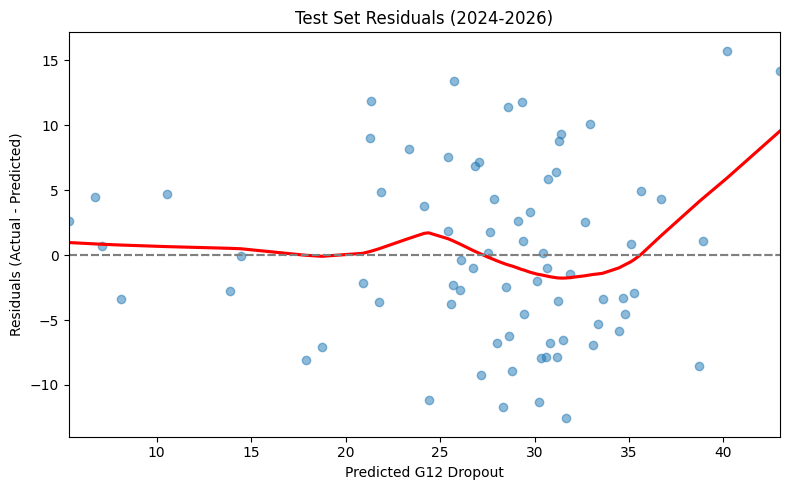

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_18932\2294970524.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


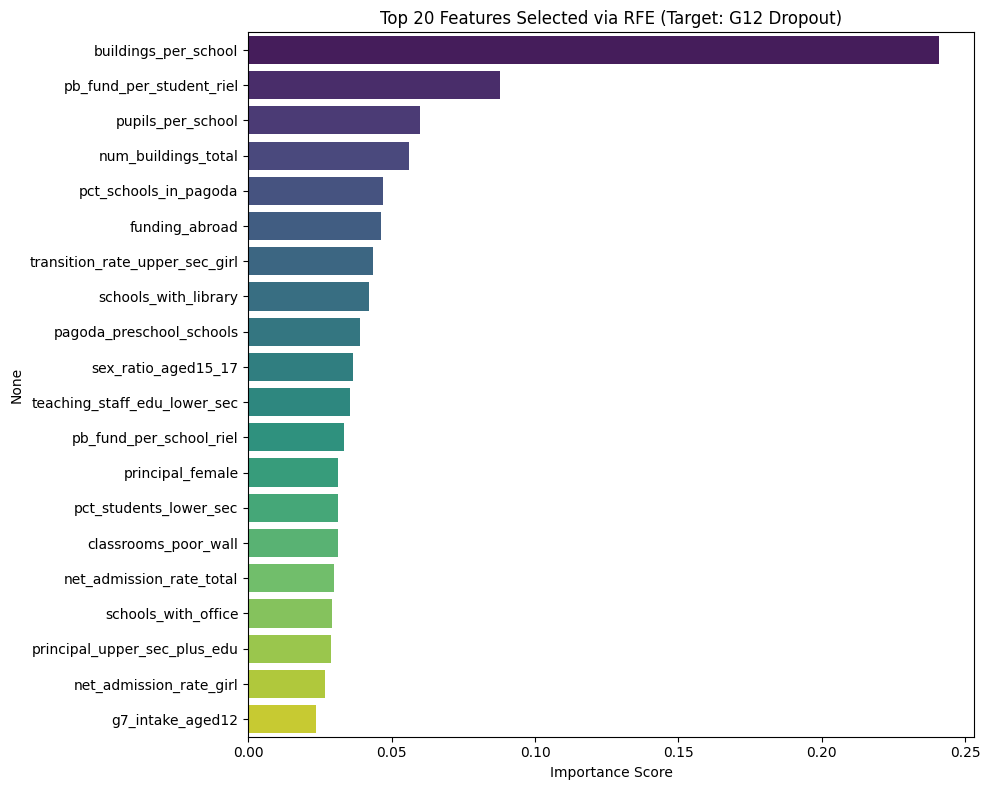


--- Feature Importances (Top 20) ---
buildings_per_school              0.240981
pb_fund_per_student_riel          0.087746
pupils_per_school                 0.059889
num_buildings_total               0.055997
pct_schools_in_pagoda             0.046845
funding_abroad                    0.046150
transition_rate_upper_sec_girl    0.043544
schools_with_library              0.041997
pagoda_preschool_schools          0.038963
sex_ratio_aged15_17               0.036540
teaching_staff_edu_lower_sec      0.035362
pb_fund_per_school_riel           0.033500
principal_female                  0.031376
pct_students_lower_sec            0.031322
classrooms_poor_wall              0.031160
net_admission_rate_total          0.030002
schools_with_office               0.029190
principal_upper_sec_plus_edu      0.028998
net_admission_rate_girl           0.026742
g7_intake_aged12                  0.023697
dtype: float64


In [17]:
# ------------------------------
# 1. Load Data
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# ------------------------------
# 2. Define column groups
# ------------------------------
banned_cols = [
    "g1_promotion", "g1_repetition", "g1_dropout",
    "g2_promotion", "g2_repetition", "g2_dropout",
    "g3_promotion", "g3_repetition", "g3_dropout",
    "g4_promotion", "g4_repetition", "g4_dropout",
    "g5_promotion", "g5_repetition", "g5_dropout",
    "g6_promotion", "g6_repetition", "g6_dropout",
    "g7_promotion", "g7_repetition", "g7_dropout",
    "g8_promotion", "g8_repetition", "g8_dropout",
    "g9_promotion", "g9_repetition", "g9_dropout",
    "g10_promotion", "g10_repetition", "g10_dropout",
    "g11_promotion", "g11_repetition", "g11_dropout",
    "g12_promotion", "g12_repetition", "g12_dropout",
    "g1_enrollment_total", "g1_enrollment_girl", "g1_repeaters_total", "g1_repeaters_girl",
    "g2_enrollment_total", "g2_enrollment_girl", "g2_repeaters_total", "g2_repeaters_girl",
    "g3_enrollment_total", "g3_enrollment_girl", "g3_repeaters_total", "g3_repeaters_girl",
    "g4_enrollment_total", "g4_enrollment_girl", "g4_repeaters_total", "g4_repeaters_girl",
    "g5_enrollment_total", "g5_enrollment_girl", "g5_repeaters_total", "g5_repeaters_girl",
    "g6_enrollment_total", "g6_enrollment_girl", "g6_repeaters_total", "g6_repeaters_girl",
    "g7_enrollment_total", "g7_enrollment_girl", "g7_repeaters_total", "g7_repeaters_girl",
    "g8_enrollment_total", "g8_enrollment_girl", "g8_repeaters_total", "g8_repeaters_girl",
    "g9_enrollment_total", "g9_enrollment_girl", "g9_repeaters_total", "g9_repeaters_girl",
    "g10_enrollment_total", "g10_enrollment_girl", "g10_repeaters_total", "g10_repeaters_girl",
    "g11_enrollment_total", "g11_enrollment_girl", "g11_repeaters_total", "g11_repeaters_girl",
    "g12_enrollment_total", "g12_enrollment_girl", "g12_repeaters_total", "g12_repeaters_girl",
    "pct_repeaters_total_primary", "pct_repeaters_total_lower_sec", "pct_repeaters_total_upper_sec",
    "pct_overage_total_primary", "pct_overage_total_lower_sec", "pct_overage_total_upper_sec",
    "pct_repeaters_girl_primary", "pct_repeaters_girl_lower_sec", "pct_repeaters_girl_upper_sec",
    "pct_overage_girl_primary", "pct_overage_girl_lower_sec", "pct_overage_girl_upper_sec"
]
metadata_cols = ['row_id', 'Year', 'Province']
target = 'g12_dropout'

# ------------------------------
# 3. Time‑based train/test split
# ------------------------------
train_mask = df['Year'].between(2016, 2023)
test_mask  = df['Year'].between(2024, 2026)

numeric_df = df.select_dtypes(include=['number'])

# Remove target, banned, and metadata from predictors
X = numeric_df.drop(columns=banned_cols + metadata_cols, errors='ignore')

# Split
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = numeric_df.loc[train_mask, target]
y_test  = numeric_df.loc[test_mask, target]

# ------------------------------
# 4. Impute missing values (fit on train only)
# ------------------------------
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# ------------------------------
# 5. RFE with Random Forest (train only)
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
selector = RFE(rf, n_features_to_select=20, step=5)
selector.fit(X_train_imputed, y_train)

selected_features_mask = selector.support_
selected_features = X_train.columns[selected_features_mask].tolist()
print(f"Selected features: {selected_features}")

# Build final datasets with selected features
X_train_selected = pd.DataFrame(X_train_imputed, columns=X_train.columns)[selected_features]
X_test_selected  = pd.DataFrame(X_test_imputed,  columns=X_train.columns)[selected_features]

# ------------------------------
# 6. Train final model & cross‑validate
# ------------------------------
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train_selected, y_train)

# 5‑fold CV on training set
cv_scores = cross_val_score(rf_final, X_train_selected, y_train,
                            cv=5, scoring='r2', n_jobs=-1)
print("\n--- Cross‑validation (Training Set) ---")
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ------------------------------
# 7. Evaluate on the test set (2024‑2026)
# ------------------------------
y_pred = rf_final.predict(X_test_selected)

test_r2   = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print("\n--- Test Set Performance (2024‑2026) ---")
print(f"R²:   {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

# ------------------------------
# 8. Residual plot
# ------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Predicted G12 Dropout')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Test Set Residuals (2024‑2026)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# ------------------------------
# 9. Feature importance plot
# ------------------------------
importances = pd.Series(rf_final.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 20 Features Selected via RFE (Target: G12 Dropout)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('top_20_features_rfe.png')
plt.show()

print("\n--- Feature Importances (Top 20) ---")
print(importances)

Selected features: ['num_classes', 'repeaters_total', 'repeaters_girl', 'teaching_staff_total', 'teaching_staff_female', 'total_staff_total', 'total_staff_female', 'num_schools_preschool', 'num_schools_college', 'two_shift_schools_lycee', 'floating_schools_lycee', 'principal_female', 'num_primary_schools', 'satellite_classes', 'pagoda_senior_high_classes', 'teaching_staff_edu_lower_sec', 'num_rooms_total', 'num_classrooms', 'sport_football', 'parent_assoc_held_meeting']

--- Cross‑validation (Training Set) ---
CV R² scores: [0.93981374 0.99322109 0.99432576 0.98386151 0.93518253]
Mean CV R²: 0.9693 (+/- 0.0525)

--- Test Set Performance (2024‑2026) ---
R²:   0.9593
RMSE: 1816.4569
MAE:  1252.6923


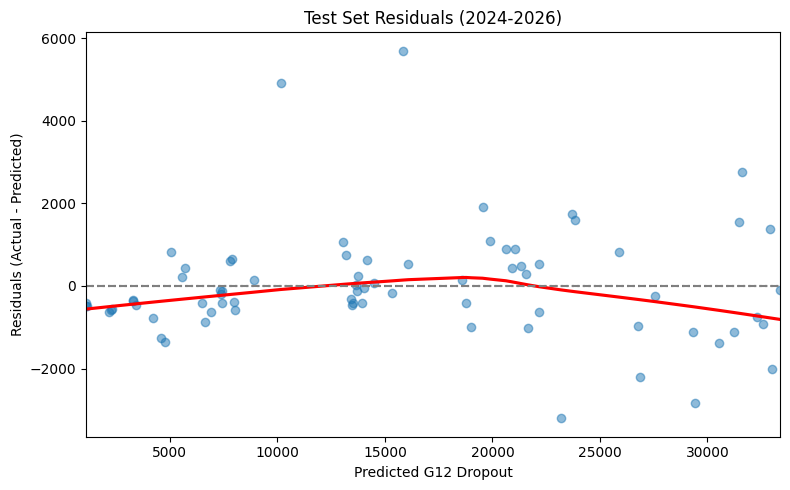

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_18932\1095406436.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


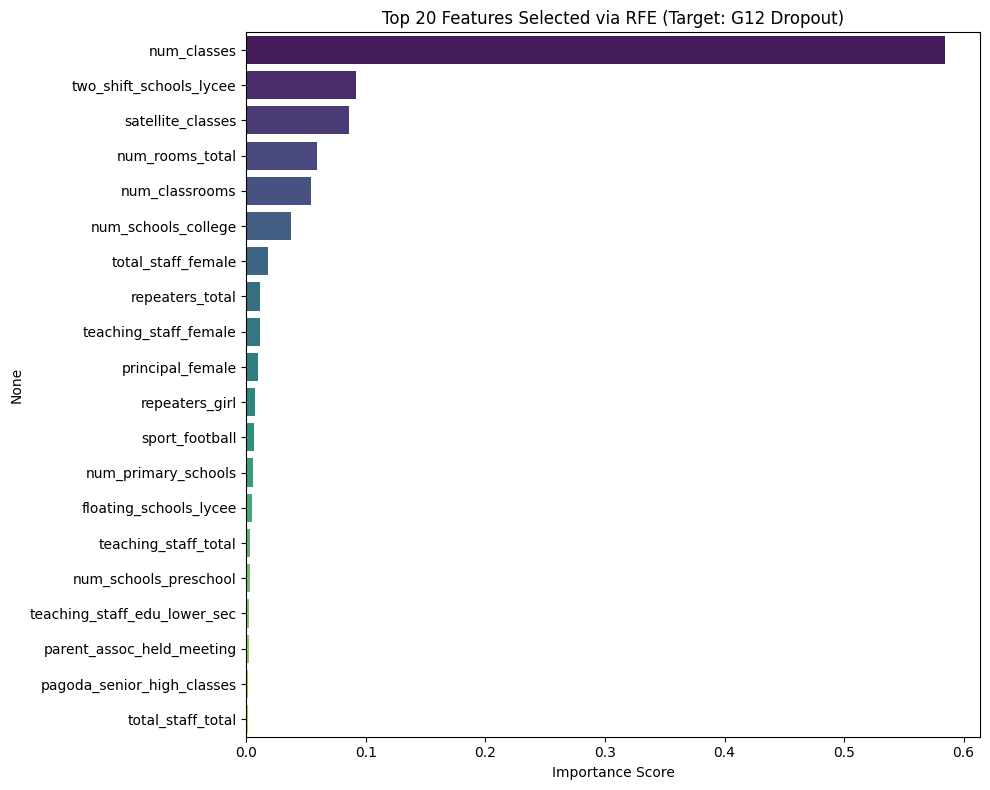


--- Feature Importances (Top 20) ---
num_classes                     0.584534
two_shift_schools_lycee         0.091680
satellite_classes               0.085930
num_rooms_total                 0.059337
num_classrooms                  0.053825
num_schools_college             0.037542
total_staff_female              0.018330
repeaters_total                 0.011497
teaching_staff_female           0.011247
principal_female                0.009391
repeaters_girl                  0.007023
sport_football                  0.006189
num_primary_schools             0.005508
floating_schools_lycee          0.004374
teaching_staff_total            0.003295
num_schools_preschool           0.002635
teaching_staff_edu_lower_sec    0.002356
parent_assoc_held_meeting       0.002048
pagoda_senior_high_classes      0.001716
total_staff_total               0.001542
dtype: float64


In [19]:
# ------------------------------
# 2. Define column groups
# ------------------------------
banned_cols = [
    "g1_promotion", "g1_repetition", "g1_dropout",
    "g2_promotion", "g2_repetition", "g2_dropout",
    "g3_promotion", "g3_repetition", "g3_dropout",
    "g4_promotion", "g4_repetition", "g4_dropout",
    "g5_promotion", "g5_repetition", "g5_dropout",
    "g6_promotion", "g6_repetition", "g6_dropout",
    "g7_promotion", "g7_repetition", "g7_dropout",
    "g8_promotion", "g8_repetition", "g8_dropout",
    "g9_promotion", "g9_repetition", "g9_dropout",
    "g10_promotion", "g10_repetition", "g10_dropout",
    "g11_promotion", "g11_repetition", "g11_dropout",
    "g12_promotion", "g12_repetition", "g12_dropout",
    "g1_enrollment_total", "g1_enrollment_girl", "g1_repeaters_total", "g1_repeaters_girl",
    "g2_enrollment_total", "g2_enrollment_girl", "g2_repeaters_total", "g2_repeaters_girl",
    "g3_enrollment_total", "g3_enrollment_girl", "g3_repeaters_total", "g3_repeaters_girl",
    "g4_enrollment_total", "g4_enrollment_girl", "g4_repeaters_total", "g4_repeaters_girl",
    "g5_enrollment_total", "g5_enrollment_girl", "g5_repeaters_total", "g5_repeaters_girl",
    "g6_enrollment_total", "g6_enrollment_girl", "g6_repeaters_total", "g6_repeaters_girl",
    "g7_enrollment_total", "g7_enrollment_girl", "g7_repeaters_total", "g7_repeaters_girl",
    "g8_enrollment_total", "g8_enrollment_girl", "g8_repeaters_total", "g8_repeaters_girl",
    "g9_enrollment_total", "g9_enrollment_girl", "g9_repeaters_total", "g9_repeaters_girl",
    "g10_enrollment_total", "g10_enrollment_girl", "g10_repeaters_total", "g10_repeaters_girl",
    "g11_enrollment_total", "g11_enrollment_girl", "g11_repeaters_total", "g11_repeaters_girl",
    "g12_enrollment_total", "g12_enrollment_girl", "g12_repeaters_total", "g12_repeaters_girl",
    "pct_repeaters_total_primary", "pct_repeaters_total_lower_sec", "pct_repeaters_total_upper_sec",
    "pct_overage_total_primary", "pct_overage_total_lower_sec", "pct_overage_total_upper_sec",
    "pct_repeaters_girl_primary", "pct_repeaters_girl_lower_sec", "pct_repeaters_girl_upper_sec",
    "pct_overage_girl_primary", "pct_overage_girl_lower_sec", "pct_overage_girl_upper_sec",
    "pop_aged6_total", "pop_aged6_girl",
    "pop_aged6_11_total", "pop_aged6_11_girl",
    "pop_aged12_14_total", "pop_aged12_14_girl",
    "pop_aged15_17_total", "pop_aged15_17_girl",
    "g1_intake_total", "g1_intake_aged6",
    "primary_enrollment_total", "primary_enrollment_aged11plus",
    "g7_intake_total", "g7_intake_aged12",
    "lower_sec_enrollment_total", "lower_sec_enrollment_aged14plus",
    "g10_intake_total", "g10_intake_aged15",
    "upper_sec_enrollment_total", "upper_sec_enrollment_aged17plus",
    "pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec",
    "enrollment_total", "enrollment_girl", 
]
metadata_cols = ['row_id', 'Year', 'Province']
target = 'g1_enrollment_total'

# ------------------------------
# 3. Time‑based train/test split
# ------------------------------
train_mask = df['Year'].between(2016, 2023)
test_mask  = df['Year'].between(2024, 2026)

numeric_df = df.select_dtypes(include=['number'])

# Remove target, banned, and metadata from predictors
X = numeric_df.drop(columns=banned_cols + metadata_cols, errors='ignore')

# Split
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = numeric_df.loc[train_mask, target]
y_test  = numeric_df.loc[test_mask, target]

# ------------------------------
# 4. Impute missing values (fit on train only)
# ------------------------------
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# ------------------------------
# 5. RFE with Random Forest (train only)
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
selector = RFE(rf, n_features_to_select=20, step=5)
selector.fit(X_train_imputed, y_train)

selected_features_mask = selector.support_
selected_features = X_train.columns[selected_features_mask].tolist()
print(f"Selected features: {selected_features}")

# Build final datasets with selected features
X_train_selected = pd.DataFrame(X_train_imputed, columns=X_train.columns)[selected_features]
X_test_selected  = pd.DataFrame(X_test_imputed,  columns=X_train.columns)[selected_features]

# ------------------------------
# 6. Train final model & cross‑validate
# ------------------------------
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train_selected, y_train)

# 5‑fold CV on training set
cv_scores = cross_val_score(rf_final, X_train_selected, y_train,
                            cv=5, scoring='r2', n_jobs=-1)
print("\n--- Cross‑validation (Training Set) ---")
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ------------------------------
# 7. Evaluate on the test set (2024‑2026)
# ------------------------------
y_pred = rf_final.predict(X_test_selected)

test_r2   = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print("\n--- Test Set Performance (2024‑2026) ---")
print(f"R²:   {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

# ------------------------------
# 8. Residual plot
# ------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Predicted G12 Dropout')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Test Set Residuals (2024‑2026)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# ------------------------------
# 9. Feature importance plot
# ------------------------------
importances = pd.Series(rf_final.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 20 Features Selected via RFE (Target: G12 Dropout)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('top_20_features_rfe.png')
plt.show()

print("\n--- Feature Importances (Top 20) ---")
print(importances)